In [111]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [3]:
# Read the data from local machine.
data = pd.read_csv("D:/Thesis/Model Apply 2018/archive/02-21-2018.csv")
data.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,21/02/2018 08:33:25,37953,5,3,135,127,135,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
2,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
3,500,17,21/02/2018 08:33:11,99743998,5,0,2500,0,500,500,...,8,4000290.0,0.0,4000290,4000290,31900000.0,37900000.0,75600000,7200397,Benign
4,500,17,21/02/2018 08:33:11,99743999,5,0,2500,0,500,500,...,8,4000286.0,0.0,4000286,4000286,31900000.0,37900000.0,75600000,7200399,Benign


In [4]:
# Drop the timestamp column as it is unnecessary.
data.drop(columns='Timestamp', inplace=True)

In [5]:
# Find the information about the dataset.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 79 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Flow Duration      1048575 non-null  int64  
 3   Tot Fwd Pkts       1048575 non-null  int64  
 4   Tot Bwd Pkts       1048575 non-null  int64  
 5   TotLen Fwd Pkts    1048575 non-null  int64  
 6   TotLen Bwd Pkts    1048575 non-null  int64  
 7   Fwd Pkt Len Max    1048575 non-null  int64  
 8   Fwd Pkt Len Min    1048575 non-null  int64  
 9   Fwd Pkt Len Mean   1048575 non-null  float64
 10  Fwd Pkt Len Std    1048575 non-null  float64
 11  Bwd Pkt Len Max    1048575 non-null  int64  
 12  Bwd Pkt Len Min    1048575 non-null  int64  
 13  Bwd Pkt Len Mean   1048575 non-null  float64
 14  Bwd Pkt Len Std    1048575 non-null  float64
 15  Flow Byts/s        1048575 non-n

In [6]:
# Replace +ve and -ve infinity with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [7]:
# See the mean,standard deviation,min, max of each column.
data.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.958764e+04,6.037952e+00,3.990401e+05,1.968099e+02,1.309663e+00,6.563581e+03,2.486527e+02,3.666938e+02,2.549479e-01,7.977144e+01,...,1.941294e+02,1.995892e+01,7.521672e+03,2.589427e+03,1.003609e+04,5.446253e+03,3.140514e+04,1.602645e+04,5.723070e+04,1.633481e+04
std,2.719338e+04,6.495848e-01,6.630337e+06,4.899047e+03,1.477423e+00,1.567596e+05,3.257857e+02,4.226960e+02,8.978105e+00,8.511139e+01,...,4.899113e+03,7.395666e-01,2.033449e+05,1.034448e+05,2.825239e+05,1.568789e+05,8.419967e+05,4.340229e+05,1.421182e+06,5.894628e+05
min,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+01,6.000000e+00,1.408000e+03,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,4.720000e+03,3.000000e+00,0.000000e+00,2.470000e+02,0.000000e+00,3.200000e+01,0.000000e+00,3.200000e+01,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.355300e+04,6.000000e+00,1.464900e+04,5.000000e+00,2.000000e+00,9.350000e+02,3.160000e+02,9.350000e+02,0.000000e+00,1.870000e+02,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.700000e+01,1.200000e+08,3.096290e+05,1.240000e+02,9.908128e+06,9.121000e+03,2.224000e+03,9.760000e+02,9.760000e+02,...,3.096280e+05,4.400000e+01,2.000000e+07,1.620000e+07,2.800000e+07,2.000000e+07,1.060000e+08,5.030000e+07,1.060000e+08,1.060000e+08


In [8]:
# Drop missing values
data.dropna(inplace=True)

In [10]:
# To see how many record fall in each classes.
data['Label'].value_counts()

DDOS attack-HOIC        686012
Benign                  360833
DDOS attack-LOIC-UDP      1730
Name: Label, dtype: int64

### Plot the orginal dataset distribution.

In [11]:
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
import plotly.express as px
init_notebook_mode(connected=True)
import plotly.graph_objs as go

fig = go.Figure(data=[
    go.Bar(name='Benign', 
           y=data["Label"].value_counts().values[1:2],
           x=['Benign'],
           text = data["Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',),
    go.Bar(name='DDOS attack-HOIC', 
           y=data["Label"].value_counts().values[0:1],
           x=['DDOS attack-HOIC'],
           text = data["Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',),
    go.Bar(name='DDOS attack-LOIC-UDP', 
           y=data["Label"].value_counts().values[2:],
           x=['DDOS attack-LOIC-UDP'],
           text = data["Label"].value_counts()[2:],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

In [12]:
# Replace the "DDOS attack-HOIC" and "DDOS attack-LOIC-UDP" as DDoS.
data.replace(to_replace=["DDOS attack-HOIC", "DDOS attack-LOIC-UDP"], value="DDoS", inplace=True)

In [13]:
data["Label"].value_counts()

DDoS      687742
Benign    360833
Name: Label, dtype: int64

In [14]:
fig = go.Figure(data=[
    go.Bar(name='Benign', 
           y=data["Label"].value_counts().values[1:2],
           x=['Benign'],
           text = data["Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',),
    go.Bar(name='DDoS', 
           y=data["Label"].value_counts().values[0:1],
           x=['DDoS'],
           text = data["Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

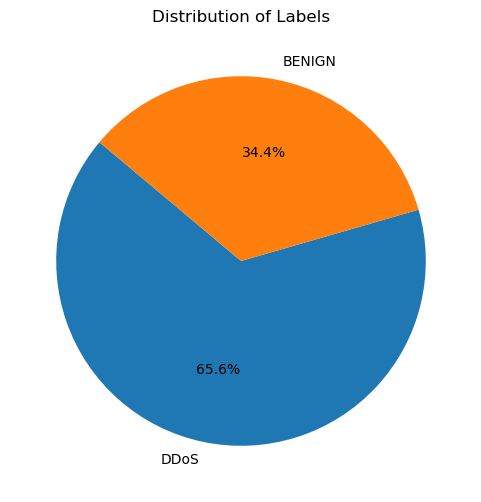

In [15]:
import matplotlib.pyplot as plt
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [687742, 360833]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

In [95]:
# Divided the data into the train independent variable and target variable.
x = data.iloc[:,:-1]
y = data['Label']

In [17]:
# Perform the train test split for feed the data into model.
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y, random_state=42)

# Data Transformation

In [21]:
# Apply the standard Scaler.
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [97]:
x = scaler.fit_transform(x)

In [22]:
# Apply the label encoding to the target cloumn.
le = LabelEncoder()
y_train = le.fit_transform(np.ravel(y_train))
y_test = le.fit_transform(np.ravel(y_test))

In [98]:
y = le.fit_transform(y)

# Different Model Apply 

### Logistic Regression

In [20]:
RawLogisticRegression = LogisticRegression()

In [25]:
RawLogisticRegression.fit(x_train,y_train)

LogisticRegression()

In [27]:
yPredLogisticRegression = RawLogisticRegression.predict(x_test)

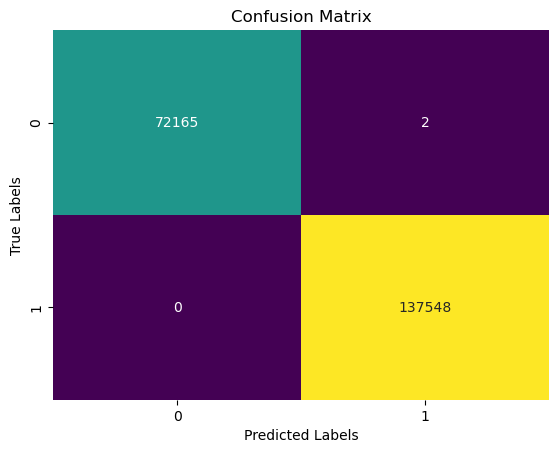

In [30]:
confMat = confusion_matrix(y_test,yPredLogisticRegression)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [32]:
# Print the classification report.
print(format(classification_report(y_test,yPredLogisticRegression)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00    137548

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [33]:
# Print accuracy, F1-score, Recall, Precision.
print("f1 Score {}".format(f1_score(y_test,yPredLogisticRegression)))
print("Recall Score {}".format(recall_score(y_test,yPredLogisticRegression)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredLogisticRegression)))
print("Precision Score {}".format(precision_score(y_test,yPredLogisticRegression)))

f1 Score 0.9999927298635395
Recall Score 1.0
Accuracy Score 0.999990463247741
Precision Score 0.9999854598327881


### Gradient Boosting

In [34]:
RawGradinetBoosting = GradientBoostingClassifier()

In [35]:
RawGradinetBoosting.fit(x_train,y_train)

GradientBoostingClassifier()

In [44]:
yPredGradientBoosting = RawGradinetBoosting.predict(x_test)

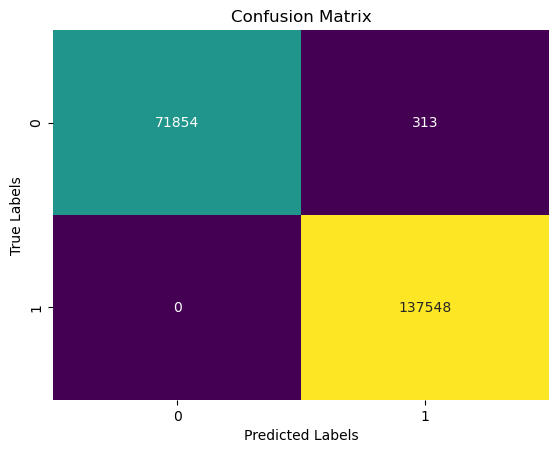

In [45]:
confMat = confusion_matrix(y_test,yPredGradientBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [40]:
print(format(classification_report(y_test,yPredGradientBoosting)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00    137548

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [42]:
print("f1 Score {}".format(f1_score(y_test,yPredGradientBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredGradientBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredGradientBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredGradientBoosting)))

f1 Score 0.9988635084546983
Recall Score 1.0
Accuracy Score 0.9985074982714637
Precision Score 0.9977295972029798


### AdaBoosting

In [46]:
RawAdaBoosting = AdaBoostClassifier()

In [47]:
RawAdaBoosting.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



AdaBoostClassifier()

In [49]:
yPredAdaBoosting = RawAdaBoosting.predict(x_test)

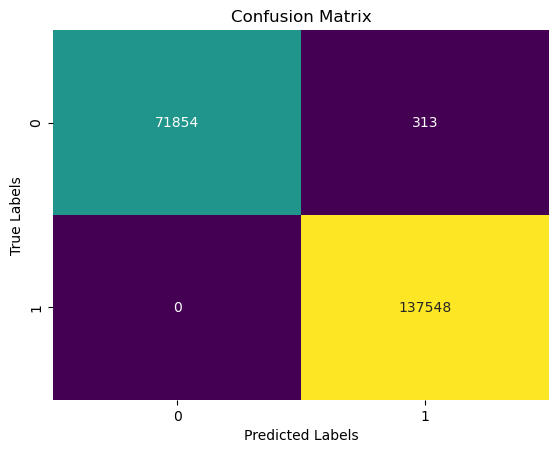

In [51]:
confMat = confusion_matrix(y_test,yPredAdaBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [52]:
print(format(classification_report(y_test,yPredAdaBoosting)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00    137548

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [53]:
print("f1 Score {}".format(f1_score(y_test,yPredAdaBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredAdaBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredAdaBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredAdaBoosting)))

f1 Score 0.9988635084546983
Recall Score 1.0
Accuracy Score 0.9985074982714637
Precision Score 0.9977295972029798


### CatBoosting

In [54]:
RawCatBoosting = CatBoostClassifier()

In [55]:
RawCatBoosting.fit(x_train,y_train)

Learning rate set to 0.182536
0:	learn: 0.1862740	total: 301ms	remaining: 5m
1:	learn: 0.0505640	total: 461ms	remaining: 3m 50s
2:	learn: 0.0182124	total: 613ms	remaining: 3m 23s
3:	learn: 0.0075367	total: 742ms	remaining: 3m 4s
4:	learn: 0.0032004	total: 873ms	remaining: 2m 53s
5:	learn: 0.0015351	total: 1.02s	remaining: 2m 48s
6:	learn: 0.0008230	total: 1.15s	remaining: 2m 43s
7:	learn: 0.0006054	total: 1.28s	remaining: 2m 39s
8:	learn: 0.0005262	total: 1.4s	remaining: 2m 34s
9:	learn: 0.0004818	total: 1.51s	remaining: 2m 29s
10:	learn: 0.0004637	total: 1.61s	remaining: 2m 25s
11:	learn: 0.0004055	total: 1.73s	remaining: 2m 22s
12:	learn: 0.0003960	total: 1.84s	remaining: 2m 19s
13:	learn: 0.0003178	total: 1.96s	remaining: 2m 18s
14:	learn: 0.0001679	total: 2.08s	remaining: 2m 16s
15:	learn: 0.0001577	total: 2.21s	remaining: 2m 15s
16:	learn: 0.0001577	total: 2.34s	remaining: 2m 15s
17:	learn: 0.0001577	total: 2.44s	remaining: 2m 13s
18:	learn: 0.0001577	total: 2.56s	remaining: 2m 12

158:	learn: 0.0001576	total: 18.9s	remaining: 1m 39s
159:	learn: 0.0001576	total: 19s	remaining: 1m 39s
160:	learn: 0.0001576	total: 19.1s	remaining: 1m 39s
161:	learn: 0.0001576	total: 19.3s	remaining: 1m 39s
162:	learn: 0.0001576	total: 19.4s	remaining: 1m 39s
163:	learn: 0.0001576	total: 19.5s	remaining: 1m 39s
164:	learn: 0.0001576	total: 19.7s	remaining: 1m 39s
165:	learn: 0.0001576	total: 19.8s	remaining: 1m 39s
166:	learn: 0.0001576	total: 19.9s	remaining: 1m 39s
167:	learn: 0.0001576	total: 20.1s	remaining: 1m 39s
168:	learn: 0.0001576	total: 20.2s	remaining: 1m 39s
169:	learn: 0.0001576	total: 20.3s	remaining: 1m 39s
170:	learn: 0.0001576	total: 20.5s	remaining: 1m 39s
171:	learn: 0.0001576	total: 20.6s	remaining: 1m 39s
172:	learn: 0.0001576	total: 20.7s	remaining: 1m 39s
173:	learn: 0.0001576	total: 20.9s	remaining: 1m 39s
174:	learn: 0.0001576	total: 21s	remaining: 1m 38s
175:	learn: 0.0001576	total: 21.1s	remaining: 1m 38s
176:	learn: 0.0001576	total: 21.3s	remaining: 1m 3

314:	learn: 0.0001576	total: 39.8s	remaining: 1m 26s
315:	learn: 0.0001576	total: 40s	remaining: 1m 26s
316:	learn: 0.0001576	total: 40.1s	remaining: 1m 26s
317:	learn: 0.0001576	total: 40.2s	remaining: 1m 26s
318:	learn: 0.0001576	total: 40.4s	remaining: 1m 26s
319:	learn: 0.0001576	total: 40.5s	remaining: 1m 26s
320:	learn: 0.0001576	total: 40.6s	remaining: 1m 25s
321:	learn: 0.0001576	total: 40.8s	remaining: 1m 25s
322:	learn: 0.0001576	total: 40.9s	remaining: 1m 25s
323:	learn: 0.0001576	total: 41s	remaining: 1m 25s
324:	learn: 0.0001576	total: 41.2s	remaining: 1m 25s
325:	learn: 0.0001576	total: 41.3s	remaining: 1m 25s
326:	learn: 0.0001576	total: 41.4s	remaining: 1m 25s
327:	learn: 0.0001576	total: 41.6s	remaining: 1m 25s
328:	learn: 0.0001576	total: 41.7s	remaining: 1m 25s
329:	learn: 0.0001576	total: 41.8s	remaining: 1m 24s
330:	learn: 0.0001576	total: 41.9s	remaining: 1m 24s
331:	learn: 0.0001576	total: 42.1s	remaining: 1m 24s
332:	learn: 0.0001576	total: 42.2s	remaining: 1m 2

470:	learn: 0.0001576	total: 1m	remaining: 1m 8s
471:	learn: 0.0001576	total: 1m	remaining: 1m 8s
472:	learn: 0.0001576	total: 1m	remaining: 1m 7s
473:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
474:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
475:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
476:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
477:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
478:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
479:	learn: 0.0001576	total: 1m 1s	remaining: 1m 7s
480:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
481:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
482:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
483:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
484:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
485:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
486:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
487:	learn: 0.0001576	total: 1m 2s	remaining: 1m 6s
488:	learn: 0.0001576	total: 1m 3s	remaining: 1m 5s
489:	learn: 0.0001576

627:	learn: 0.0001576	total: 1m 23s	remaining: 49.7s
628:	learn: 0.0001576	total: 1m 24s	remaining: 49.6s
629:	learn: 0.0001576	total: 1m 24s	remaining: 49.5s
630:	learn: 0.0001576	total: 1m 24s	remaining: 49.4s
631:	learn: 0.0001576	total: 1m 24s	remaining: 49.3s
632:	learn: 0.0001576	total: 1m 24s	remaining: 49.2s
633:	learn: 0.0001576	total: 1m 24s	remaining: 49.1s
634:	learn: 0.0001576	total: 1m 25s	remaining: 49s
635:	learn: 0.0001576	total: 1m 25s	remaining: 48.8s
636:	learn: 0.0001576	total: 1m 25s	remaining: 48.7s
637:	learn: 0.0001576	total: 1m 25s	remaining: 48.6s
638:	learn: 0.0001576	total: 1m 25s	remaining: 48.4s
639:	learn: 0.0001576	total: 1m 25s	remaining: 48.3s
640:	learn: 0.0001576	total: 1m 26s	remaining: 48.2s
641:	learn: 0.0001576	total: 1m 26s	remaining: 48.1s
642:	learn: 0.0001576	total: 1m 26s	remaining: 48s
643:	learn: 0.0001576	total: 1m 26s	remaining: 47.9s
644:	learn: 0.0001576	total: 1m 26s	remaining: 47.8s
645:	learn: 0.0001576	total: 1m 27s	remaining: 47.

783:	learn: 0.0001576	total: 1m 46s	remaining: 29.3s
784:	learn: 0.0001576	total: 1m 46s	remaining: 29.2s
785:	learn: 0.0001576	total: 1m 46s	remaining: 29s
786:	learn: 0.0001576	total: 1m 46s	remaining: 28.9s
787:	learn: 0.0001576	total: 1m 46s	remaining: 28.8s
788:	learn: 0.0001576	total: 1m 47s	remaining: 28.6s
789:	learn: 0.0001576	total: 1m 47s	remaining: 28.5s
790:	learn: 0.0001576	total: 1m 47s	remaining: 28.4s
791:	learn: 0.0001576	total: 1m 47s	remaining: 28.2s
792:	learn: 0.0001576	total: 1m 47s	remaining: 28.1s
793:	learn: 0.0001576	total: 1m 47s	remaining: 28s
794:	learn: 0.0001576	total: 1m 47s	remaining: 27.8s
795:	learn: 0.0001576	total: 1m 48s	remaining: 27.7s
796:	learn: 0.0001576	total: 1m 48s	remaining: 27.5s
797:	learn: 0.0001576	total: 1m 48s	remaining: 27.4s
798:	learn: 0.0001576	total: 1m 48s	remaining: 27.3s
799:	learn: 0.0001576	total: 1m 48s	remaining: 27.2s
800:	learn: 0.0001576	total: 1m 48s	remaining: 27s
801:	learn: 0.0001576	total: 1m 48s	remaining: 26.9s

940:	learn: 0.0001576	total: 2m 7s	remaining: 8s
941:	learn: 0.0001576	total: 2m 7s	remaining: 7.86s
942:	learn: 0.0001576	total: 2m 7s	remaining: 7.72s
943:	learn: 0.0001576	total: 2m 7s	remaining: 7.59s
944:	learn: 0.0001576	total: 2m 8s	remaining: 7.45s
945:	learn: 0.0001576	total: 2m 8s	remaining: 7.32s
946:	learn: 0.0001576	total: 2m 8s	remaining: 7.18s
947:	learn: 0.0001576	total: 2m 8s	remaining: 7.05s
948:	learn: 0.0001576	total: 2m 8s	remaining: 6.91s
949:	learn: 0.0001576	total: 2m 8s	remaining: 6.77s
950:	learn: 0.0001576	total: 2m 8s	remaining: 6.64s
951:	learn: 0.0001576	total: 2m 9s	remaining: 6.5s
952:	learn: 0.0001576	total: 2m 9s	remaining: 6.37s
953:	learn: 0.0001576	total: 2m 9s	remaining: 6.24s
954:	learn: 0.0001576	total: 2m 9s	remaining: 6.1s
955:	learn: 0.0001576	total: 2m 9s	remaining: 5.96s
956:	learn: 0.0001576	total: 2m 9s	remaining: 5.83s
957:	learn: 0.0001576	total: 2m 9s	remaining: 5.69s
958:	learn: 0.0001576	total: 2m 10s	remaining: 5.56s
959:	learn: 0.00

In [56]:
yPredCatBoosting = RawCatBoosting.predict(x_test)

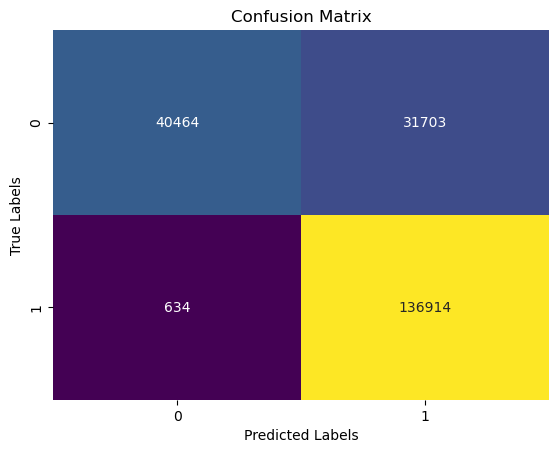

In [59]:
confMat = confusion_matrix(y_test,yPredCatBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [60]:
print(format(classification_report(y_test,yPredCatBoosting)))

              precision    recall  f1-score   support

           0       0.98      0.56      0.71     72167
           1       0.81      1.00      0.89    137548

    accuracy                           0.85    209715
   macro avg       0.90      0.78      0.80    209715
weighted avg       0.87      0.85      0.83    209715



In [61]:
print("f1 Score {}".format(f1_score(y_test,yPredCatBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredCatBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredCatBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredCatBoosting)))

f1 Score 0.8943804811131253
Recall Score 0.9953906999738273
Accuracy Score 0.8458050211000644
Precision Score 0.8119821844772472


### LightGBM

In [62]:
RawLightGBM = LGBMClassifier()

In [63]:
RawLightGBM.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 550194, number of negative: 288666
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.229086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7729
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.655883 -> initscore=0.645001
[LightGBM] [Info] Start training from score 0.645001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

LGBMClassifier()

In [64]:
yPredLightGBM = RawLightGBM.predict(x_test)

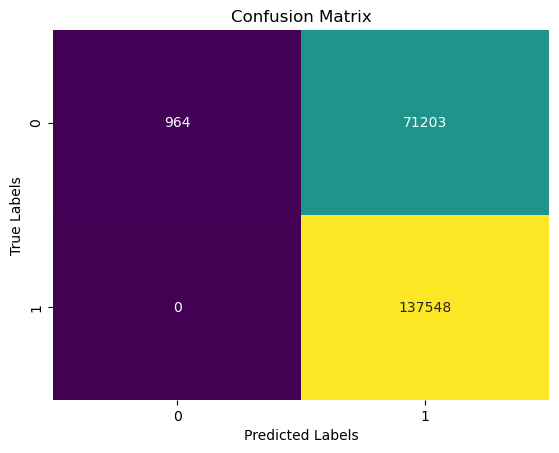

In [65]:
confMat = confusion_matrix(y_test,yPredLightGBM)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [66]:
print(format(classification_report(y_test,yPredLightGBM)))

              precision    recall  f1-score   support

           0       1.00      0.01      0.03     72167
           1       0.66      1.00      0.79    137548

    accuracy                           0.66    209715
   macro avg       0.83      0.51      0.41    209715
weighted avg       0.78      0.66      0.53    209715



In [67]:
print("f1 Score {}".format(f1_score(y_test,yPredLightGBM)))
print("Recall Score {}".format(recall_score(y_test,yPredLightGBM)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredLightGBM)))
print("Precision Score {}".format(precision_score(y_test,yPredLightGBM)))

f1 Score 0.7943886641312854
Recall Score 1.0
Accuracy Score 0.6604773144505639
Precision Score 0.6589094183979957


### XGBoosting

In [70]:
RawXGBoost = XGBClassifier()

In [71]:
RawXGBoost.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [72]:
yPredXGBoost = RawXGBoost.predict(x_test)

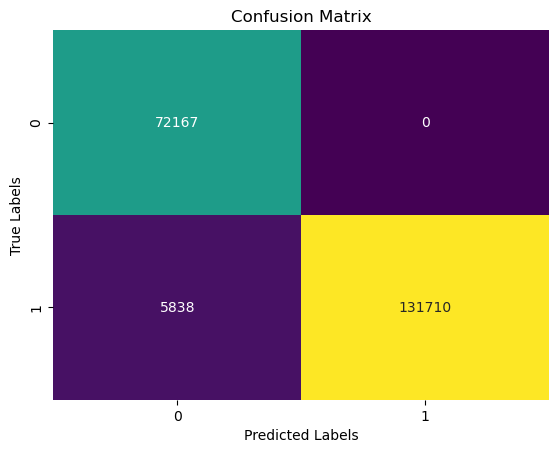

In [73]:
confMat = confusion_matrix(y_test,yPredXGBoost)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [74]:
print(format(classification_report(y_test,yPredXGBoost)))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     72167
           1       1.00      0.96      0.98    137548

    accuracy                           0.97    209715
   macro avg       0.96      0.98      0.97    209715
weighted avg       0.97      0.97      0.97    209715



In [77]:
print("f1 Score {}".format(f1_score(y_test,yPredXGBoost)))
print("Recall Score {}".format(recall_score(y_test,yPredXGBoost)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredXGBoost)))
print("Precision Score {}".format(precision_score(y_test,yPredXGBoost)))

f1 Score 0.9783181929599121
Recall Score 0.9575566347747695
Accuracy Score 0.9721622201559259
Precision Score 1.0


### Decision Tree

In [78]:
RawDecisionTree = DecisionTreeClassifier()

In [79]:
RawDecisionTree.fit(x_train,y_train)

DecisionTreeClassifier()

In [80]:
yPredDecisionTree = RawDecisionTree.predict(x_test)

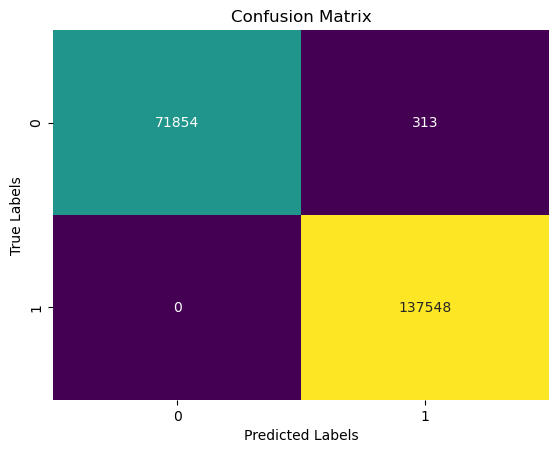

In [82]:
confMat = confusion_matrix(y_test,yPredDecisionTree)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [83]:
print(format(classification_report(y_test,yPredDecisionTree)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00    137548

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [86]:
print("f1 Score {}".format(f1_score(y_test,yPredDecisionTree)))
print("Recall Score {}".format(recall_score(y_test,yPredDecisionTree)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredDecisionTree)))
print("Precision Score {}".format(precision_score(y_test,yPredDecisionTree)))

f1 Score 0.9988635084546983
Recall Score 1.0
Accuracy Score 0.9985074982714637
Precision Score 0.9977295972029798


## Voting Classifier

### Hard Voting

In [93]:
estimators = [("lr",RawLogisticRegression),("Gb",RawGradinetBoosting),("Ab",RawAdaBoosting),("Xb",RawXGBoost)]

In [101]:
RawVotingClassifier = VotingClassifier(estimators=estimators,voting='hard')
result = cross_val_score(RawVotingClassifier,x,y,cv=10,scoring='accuracy')
# print(np.round(np.mean(result),2))

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



1.0


In [106]:
print(np.mean(result)*100)

99.83215396059431


### Soft Voting

In [107]:
RawVotingClassifier = VotingClassifier(estimators=estimators,voting='soft')
result = cross_val_score(RawVotingClassifier,x,y,cv=5,scoring='accuracy')

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



In [109]:
print(np.mean(result)*100)

99.83215316024129


### Stacking

In [110]:
StackEstimetors = [("Lr",RawLogisticRegression),("Dt",RawDecisionTree),("Ab",RawAdaBoosting)]

In [112]:
RawStacking = StackingClassifier(estimators=StackEstimetors,final_estimator=RawGradinetBoosting,cv=5)

In [113]:
RawStacking.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



StackingClassifier(cv=5,
                   estimators=[('Lr', LogisticRegression()),
                               ('Dt', DecisionTreeClassifier()),
                               ('Ab', AdaBoostClassifier())],
                   final_estimator=GradientBoostingClassifier())

In [114]:
yPredStacking = RawStacking.predict(x_test)

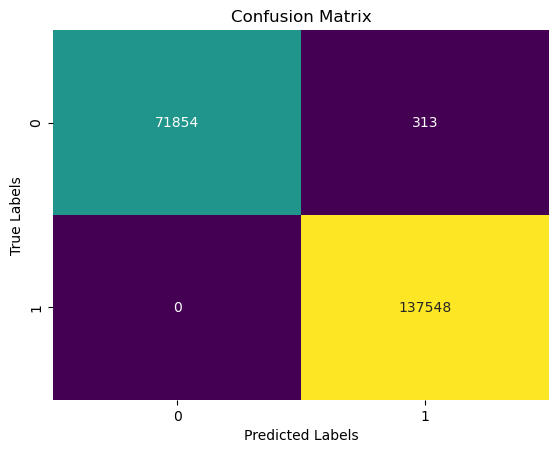

In [116]:
confMat = confusion_matrix(y_test,yPredStacking)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [117]:
print(format(classification_report(y_test,yPredStacking)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00    137548

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [118]:
print("f1 Score {}".format(f1_score(y_test,yPredStacking)))
print("Recall Score {}".format(recall_score(y_test,yPredStacking)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredStacking)))
print("Precision Score {}".format(precision_score(y_test,yPredStacking)))

f1 Score 0.9988635084546983
Recall Score 1.0
Accuracy Score 0.9985074982714637
Precision Score 0.9977295972029798
